0
              YEAR          DOY          T2M      T2M_MAX     T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.00000   
mean   2020.131451   180.121227    26.802422    29.163493    25.03813   
min    2015.000000     1.000000    22.680000    25.410000    20.03000   
25%    2017.000000    86.000000    25.670000    28.090000    23.71000   
50%    2020.000000   179.000000    26.990000    29.080000    25.37500   
75%    2023.000000   272.000000    27.900000    30.170000    26.31000   
max    2026.000000   366.000000    29.970000    33.930000    28.01000   
std       3.248907   106.294767     1.325388     1.371155     1.53544   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean      4.125363     3.740256    77.128038     4.105370     5.189248   
min       0.940000     0.000000    60.060000     1.120000     1.550000   
25%       3.330000     0.110000    73.167500

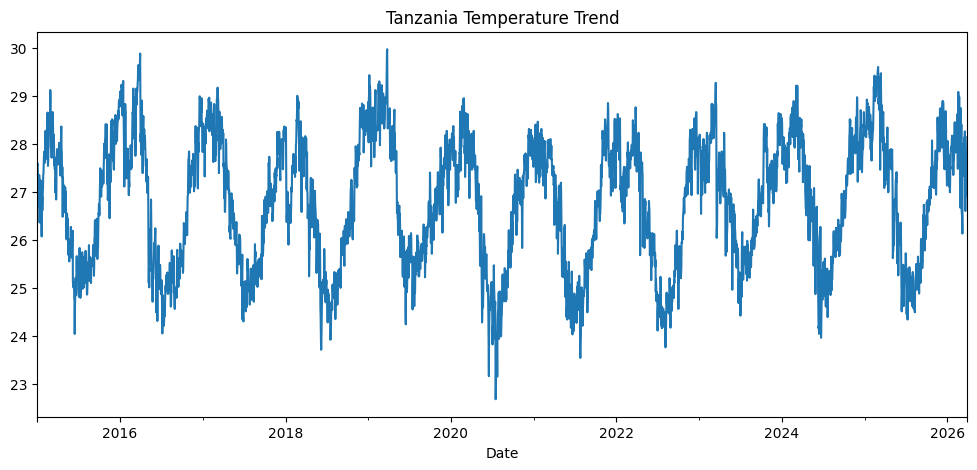

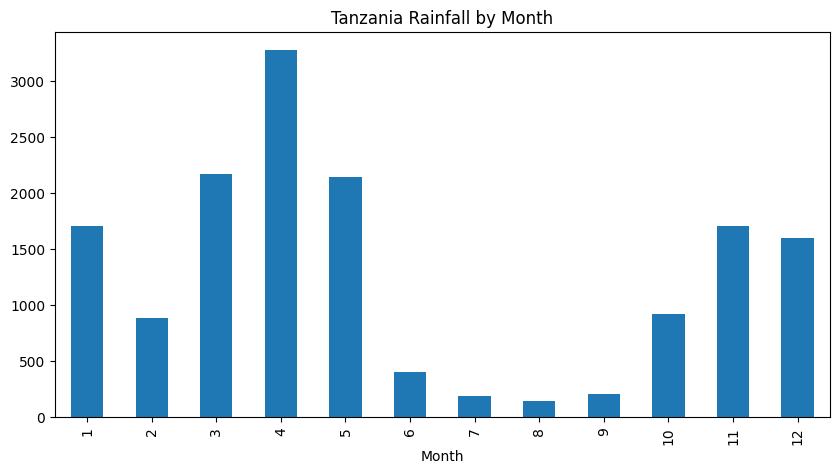

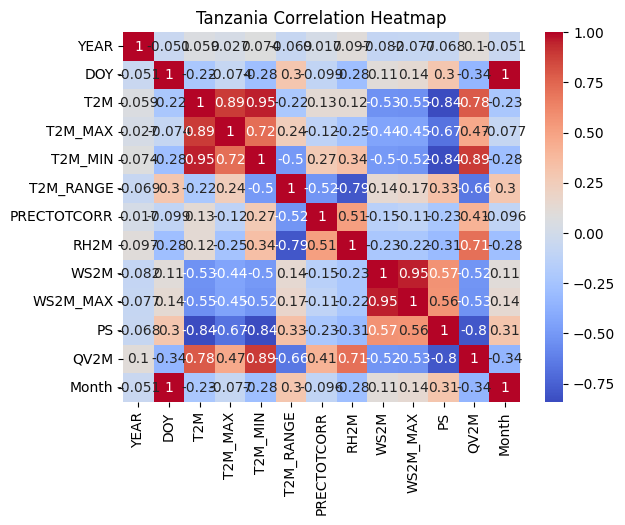

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/tanzania.csv")

df["Country"] = "Tanzania"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.replace(-999, np.nan, inplace=True)

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.describe())

print(df.isna().sum())

df.ffill(inplace=True)

monthly_temp = df.groupby("Date")["T2M"].mean()

plt.figure(figsize=(12,5))
monthly_temp.plot()
plt.title("Tanzania Temperature Trend")
plt.show()

monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Tanzania Rainfall by Month")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Tanzania Correlation Heatmap")
plt.show()
